The eigenvalues $\epsilon_{n,k_x,k_y}$ and eigenstates $\psi_{n,k_x,k_y}$ which diagonalize spits out are for each $(k_x,k_y)$ order from lowest to highest. For most applications this is okay. However, in certain applications of multiband systems crossing of bands can cause problems. At the crossing the energy and the eigenstate are discontinuous because the labels of the bands do not exchange. 

Here, we learn how to reorder bands such that it fits our needs. We can also structure them in terms of additional quantum number, e.g. spin.

In [2]:
%load_ext autoreload
%autoreload 2

from blochK import Hamiltonian2D
import numpy as np
from numpy import pi,cos,sin,exp

import matplotlib.pyplot as plt
import matplotlib

from blochK.plotting.utils import extent #for getting the correct extent
from blochK.plotting.plotting import plot_bandstruc, plot_FS

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Reshaping using conserved quantities

Let's first import a Hamiltonian with from the basics tutorial. It has spin split bands. We want to get the spin-up and spin-downs bands seperatley.

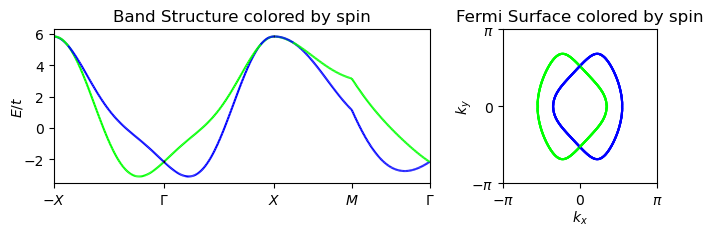

In [136]:
import blochK.hamiltonian_testing as hamiltonian_testing

H_pAFM = Hamiltonian2D(hamiltonian_testing.H_pAFM_diag_fct,
                       param=dict(delta=1,mu=-3),
                       basis_states=['up','down'],
                       basis=['spin'])
H_pAFM.add_operator('spin', np.array([1,-1])) 

fig,axs = plt.subplots(1,2,gridspec_kw={'width_ratios': [2,1]},figsize=(8,2))
path = ['-X',r'\Gamma','X','M',r'\Gamma'] 
axs[0].set_title('Band Structure colored by spin')
axs[1].set_title('Fermi Surface colored by spin')
plot_bandstruc(axs[0], H_pAFM, N_samples=100, labels_points_path=path, coloring_operator=H_pAFM.operator.spin)
plot_FS(axs[1], H_pAFM, coloring_operator=H_pAFM.operator.spin)

The shape of the original eigenvalues array is: (2, 31, 31)
The shape of the reshaped eigenvalues array is: (2, 1, 31, 31)


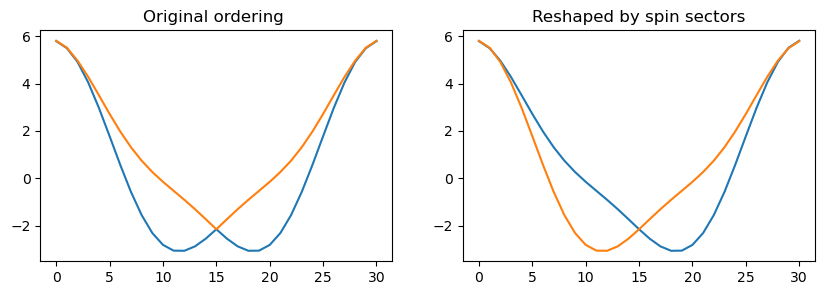

In [135]:
from blochK.band_sorting import reshape_states


es,psis = H_pAFM.diagonalize(*H_pAFM.BZ.sample(31))

es_new, psis_new = reshape_states(es, psis, H_pAFM.operator.spin) #reshape using the spin operator

print('The shape of the original eigenvalues array is:', es.shape)
print('The shape of the reshaped eigenvalues array is:', es_new.shape)

fig,axs = plt.subplots(1,2,figsize=(10,3))

axs[0].set_title('Original ordering ')
for e in es:
    axs[0].plot(e[:,e.shape[-1]//2], '-')
axs[1].set_title('Reshaped by spin sectors')
for e in es_new:
    axs[1].plot(e[0,:,e.shape[-1]//2], '-')


# Reordering bands

This needs to be better understood...

In [ ]:
def Hsquare_fct(kx,ky,t1=1,t2=1,mu=-1,dmu=0): 
    """
    t1: NN hopping first orbital
    t2: NN hopping second orbital
    dmu: orbital energy difference
    mu: chemical potential
    """
    Hk = np.zeros((2,2,*kx.shape),dtype=complex) #Basis (up,down)

    #set hamiltonian structure
    Hk[0,0] = -2*t1*cos(kx) - 2*t1*cos(ky) - mu +dmu
    Hk[1,1] = -2*t2*cos(kx) - 2*t2*cos(ky) - mu -dmu
    Hk[0,1] = 0.3*sin(ky)

    #make hermitian
    Hk[1,0] = np.conjugate(Hk[0,1])

    return Hk

# Define the Hamiltonian as a Hamiltonian2D object
Hsquare = Hamiltonian2D(Hsquare_fct, basis_states=['1','2'], basis=['orbital'], n1=np.array([1,0]), n2=np.array([0,1]))
Hsquare.update_params(dict(t1=2,t2=1,mu=0,dmu=1))


# Compute eigenvalues and eigenstates on a path in k-space
# kxs = np.linspace(-pi,pi,101)
# ks = np.array([[kx,0] for kx in kxs]).T
# es,psis = Hsquare.diagonalize(*ks)
ks = Hsquare.BZ.sample(40)
es,psis = Hsquare.diagonalize(*ks)


In [87]:

es_reordered, psis_reordered = reorder_bands_2D(es,psis,verbose=True)

Matched (0,0) → (1,0), perm=[0 1]
Matched (0,0) → (0,1), perm=[0 1]
Matched (1,0) → (2,0), perm=[0 1]
Matched (1,0) → (1,1), perm=[0 1]
Matched (0,1) → (0,2), perm=[0 1]
Matched (2,0) → (3,0), perm=[0 1]
Matched (2,0) → (2,1), perm=[0 1]
Matched (1,1) → (1,2), perm=[0 1]
Matched (0,2) → (0,3), perm=[0 1]
Matched (3,0) → (4,0), perm=[0 1]
Matched (3,0) → (3,1), perm=[0 1]
Matched (2,1) → (2,2), perm=[0 1]
Matched (1,2) → (1,3), perm=[0 1]
Matched (0,3) → (0,4), perm=[0 1]
Matched (4,0) → (5,0), perm=[0 1]
Matched (4,0) → (4,1), perm=[0 1]
Matched (3,1) → (3,2), perm=[0 1]
Matched (2,2) → (2,3), perm=[0 1]
Matched (1,3) → (1,4), perm=[0 1]
Matched (0,4) → (0,5), perm=[0 1]
Matched (5,0) → (6,0), perm=[0 1]
Matched (5,0) → (5,1), perm=[0 1]
Matched (4,1) → (4,2), perm=[0 1]
Matched (3,2) → (3,3), perm=[0 1]
Matched (2,3) → (2,4), perm=[0 1]
Matched (1,4) → (1,5), perm=[0 1]
Matched (0,5) → (0,6), perm=[0 1]
Matched (6,0) → (7,0), perm=[0 1]
Matched (6,0) → (6,1), perm=[0 1]
Matched (5,1) 

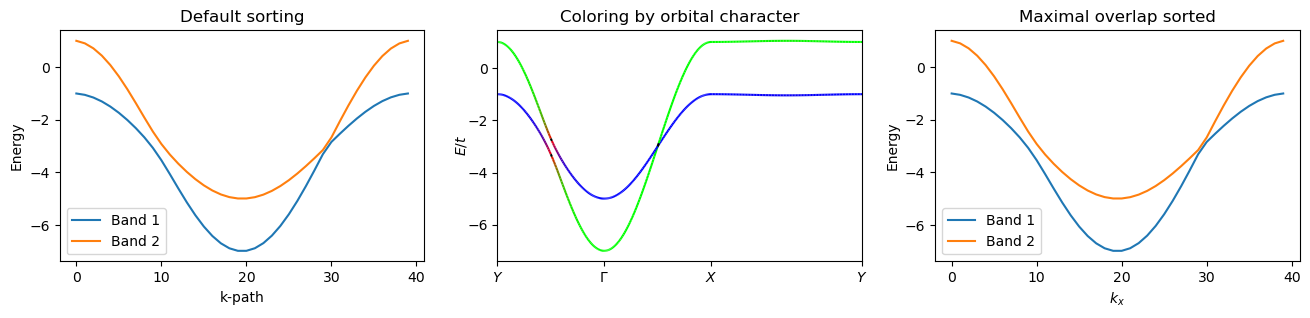

In [104]:
fig,axs = plt.subplots(1,3,figsize=(16,3))
idx = es.shape[-1]//2

#plot the default sorting
e_path = np.concatenate((es[:,idx,idx:][:,::-1],es[:,idx:,idx]),axis=1)
axs[0].plot(e_path[0],'-',label='Band 1')
axs[0].plot(e_path[1],'-',label='Band 2')
axs[0].set_xlabel('k-path')
axs[0].set_ylabel('Energy')
axs[0].set_title('Default sorting')
axs[0].legend()

#color by orbital character
plot_bandstruc(axs[1],Hsquare,coloring_operator=np.array([1,-1]),labels_points_path=['Y',r'\Gamma','X','Y'])
axs[1].set_title('Coloring by orbital character')

#plot the overlap sorting
e_path = np.concatenate((es_reordered[:,idx,idx:][:,::-1],es_reordered[:,idx:,idx]),axis=1)
axs[2].plot(e_path[0],'-',label='Band 1')
axs[2].plot(e_path[1],'-',label='Band 2')
axs[2].set_xlabel('$k_x$')
axs[2].set_ylabel('Energy')
axs[2].set_title('Maximal overlap sorted')
axs[2].legend()

In [89]:
from scipy.optimize import linear_sum_assignment

def reorder_bands_2D(es, psi, start=(0,0), verbose=False):
    """
    Reorder bands on a 2D k-grid by maximizing eigenvector overlaps.

    Parameters
    ----------
    es : array, shape (band, Nkx, ...)
        eigenvalues
    psi : array, shape (band, Nkx, ..., orbital)
        eigenvectors; psi[n,kx,ky] is the eigenvector for band n
    start : tuple
        starting k-point for continuity (kx0, ky0)
    verbose : bool
        if True prints diagnostic matches

    Returns
    -------
    es_new  : reordered eigenvalues (same shape)
    psi_new : reordered eigenvectors (same shape)
    """

    nb, Nkx, Nky = es.shape
    _, _, _, Nint = psi.shape

    es_new  = np.zeros_like(es)
    psi_new = np.zeros_like(psi)

    # mark visited sites
    visited = np.zeros((Nkx, Nky), dtype=bool)

    # BFS queue
    from collections import deque
    queue = deque([start])

    # copy the reference point
    kx0, ky0 = start
    es_new[:, kx0, ky0]  = es[:, kx0, ky0]
    psi_new[:, kx0, ky0] = psi[:, kx0, ky0]
    visited[kx0, ky0] = True

    # nearest neighbors (4-connected)
    neighbors = [(1,0), (-1,0), (0,1), (0,-1)]

    while queue:
        kx, ky = queue.popleft()
        psi_ref = psi_new[:, kx, ky]  # shape (nb, Nint)

        for dx, dy in neighbors:
            kx2, ky2 = kx + dx, ky + dy
            if not (0 <= kx2 < Nkx and 0 <= ky2 < Nky):
                continue
            if visited[kx2, ky2]:
                continue

            # eigenvectors at neighbor
            psi_next = psi[:, kx2, ky2]  # shape (nb, Nint)

            # compute overlap matrix | <ref_n | next_m> |
            O = np.abs(psi_ref.conj() @ psi_next.T)  # (nb, nb)

            # Hungarian matching: maximize overlaps
            row_ind, col_ind = linear_sum_assignment(-O)

            perm = np.zeros(nb, dtype=int)
            perm[row_ind] = col_ind

            # apply permutation + phase fix
            psi_perm = np.zeros_like(psi_next)
            es_perm  = np.zeros(nb)

            for n_ref in range(nb):
                m_next = perm[n_ref]
                v = psi_next[m_next]

                # phase alignment: make <u_ref | v> real positive
                ov = np.vdot(psi_ref[n_ref], v)
                if np.abs(ov) > 0:
                    v = v * np.exp(-1j*np.angle(ov))

                psi_perm[n_ref] = v / np.linalg.norm(v)
                es_perm[n_ref]  = es[m_next, kx2, ky2]

            psi_new[:, kx2, ky2] = psi_perm
            es_new[:,  kx2, ky2] = es_perm

            visited[kx2, ky2] = True
            queue.append((kx2, ky2))

            if verbose:
                print(f"Matched ({kx},{ky}) → ({kx2},{ky2}), perm={perm}")

    return es_new, psi_new

In [46]:
for n in range(psis.shape[0]):
    print(np.linalg.norm(psis[n,0,0]))

1.0
1.0


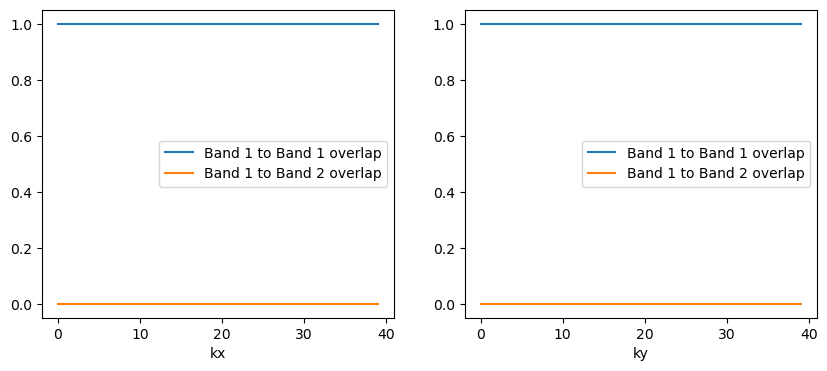

In [99]:
O = np.array([[1,0],[0,1]]) #identity operator

overlap = np.abs(np.einsum('nxya,ab,mxyb->nmxy',np.conjugate(psis),O,np.roll(psis,1,axis=1)))**2



fig,axs = plt.subplots(1,2,figsize=(10,4))
axs[0].plot(overlap[0,0,:,0],label='Band 1 to Band 1 overlap')
axs[0].plot(overlap[0,1,:,0],label='Band 1 to Band 2 overlap')
axs[0].set_xlabel('kx')
axs[0].legend()

axs[1].plot(overlap[0,0,0,:],label='Band 1 to Band 1 overlap')
axs[1].plot(overlap[0,1,0,:],label='Band 1 to Band 2 overlap')
axs[1].set_xlabel('ky')
axs[1].legend()

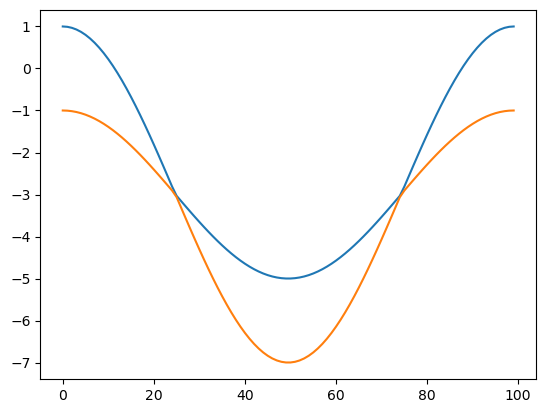

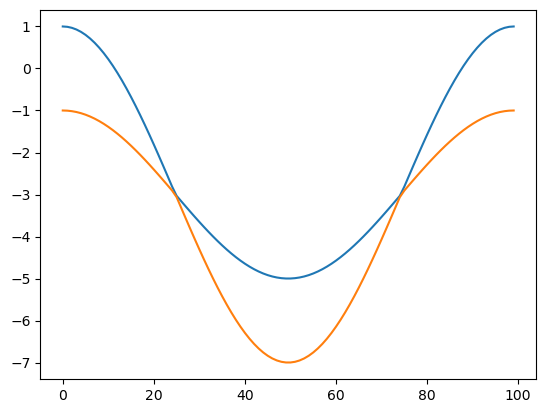

In [110]:
def ek(kx,ky,t1=2,t2=1,mu=0,dmu=1):
    Hk00 = -2*t1*cos(kx) - 2*t1*cos(ky) - mu +dmu
    Hk11 = -2*t2*cos(kx) - 2*t2*cos(ky) - mu -dmu
    Hk01 = 0.*sin(ky)

    d0 = (Hk00 + Hk11)/2
    dx = Hk01
    dz = (Hk00 - Hk11)/2

    return np.array([d0 + np.sqrt(dx**2 + dz**2), d0 - np.sqrt(dx**2 + dz**2)])

plt.plot(ek(np.linspace(-pi,pi,100),0)[0],label='Analytical Band 1')
plt.plot(ek(np.linspace(-pi,pi,100),0)[1],label='Analytical Band 2')
plt.show()

plt.plot(ek(0,np.linspace(-pi,pi,100))[0],label='Analytical Band 1')
plt.plot(ek(0,np.linspace(-pi,pi,100))[1],label='Analytical Band 2')
plt.show()
